# InhibitorCNN v2 — MobileNetV3 Small fine-tuning

Same 3-class task as v1, but using a MobileNetV3 Small backbone pre-trained on ImageNet.

| Class | Label | QuickDraw shape |
|-------|-------|-----------------|
| 0 | **Selective** | square |
| 1 | **Toxic** | triangle |
| 2 | **Inactive** | circle / star / zigzag / line / cloud |

**Strategy:**
- Phase 1 (5 epochs): freeze backbone, train classifier head only at LR=1e-3
- Phase 2 (20 epochs): unfreeze all, fine-tune at LR=1e-4

Input pipeline: 28×28 grayscale → 224×224 → 3-channel (repeat) → ImageNet normalisation

## Config

In [1]:
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

DATA_DIR  = Path.cwd() / 'data'
CKPT_DIR  = Path.cwd() / 'checkpoints'
CKPT_DIR.mkdir(parents=True, exist_ok=True)

SAMPLES_PER_CLASS = 10_000
BATCH_SIZE        = 64        # smaller than v1 — 224×224 is heavier
EPOCHS_HEAD       = 3         # phase 1: head only
EPOCHS_FULL       = 10        # phase 2: full fine-tune
LR_HEAD           = 1e-3
LR_FULL           = 1e-4
WEIGHT_DECAY      = 1e-4
NUM_WORKERS       = 4

CLASS_NAMES = ['Selective (square)', 'Toxic (triangle)', 'Inactive (other)']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


/aloy/home/ddalton/miniconda3/envs/torch_vis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Dataset

Extends the raw QuickDraw `.npy` files with a transform pipeline that converts
28×28 grayscale sketches into the 224×224 RGB tensors MobileNetV3 expects.

In [2]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

SELECTIVE_CATEGORIES = ['square', 'hexagon']
INACTIVE_CATEGORIES  = ['circle', 'star', 'zigzag', 'line', 'cloud']


def build_transforms(augment: bool):
    ops = [T.Resize(224)]
    if augment:
        ops += [
            T.RandomAffine(degrees=180, translate=(0.1, 0.1), scale=(0.85, 1.15)),
            T.RandomPerspective(distortion_scale=0.3, p=0.5),
            T.GaussianBlur(kernel_size=5, sigma=(0.1, 1.5)),
        ]
    # grayscale → 3-channel, then ImageNet normalisation
    ops += [
        T.Lambda(lambda t: t.repeat(3, 1, 1)),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
    return T.Compose(ops)


class QuickDrawDataset(Dataset):
    def __init__(self, data_dir, split='train', train_ratio=0.85,
                 samples_per_class=SAMPLES_PER_CLASS, seed=42):
        data_dir = Path(data_dir)
        rng = np.random.default_rng(seed)

        selective_parts = [np.load(data_dir / f'{c}.npy') for c in SELECTIVE_CATEGORIES]
        selective_all   = np.concatenate(selective_parts, axis=0)

        inactive_parts = [np.load(data_dir / f'{c}.npy') for c in INACTIVE_CATEGORIES]
        inactive_all   = np.concatenate(inactive_parts, axis=0)

        sources = [
            (selective_all,                       0),
            (np.load(data_dir / 'triangle.npy'), 1),
            (inactive_all,                        2),
        ]

        images, labels = [], []
        for data, label in sources:
            idx = rng.choice(len(data), samples_per_class, replace=False)
            images.append(data[idx])
            labels.extend([label] * samples_per_class)

        images = np.concatenate(images, axis=0)
        labels = np.array(labels, dtype=np.int64)

        perm = rng.permutation(len(labels))
        images, labels = images[perm], labels[perm]

        n_train = int(len(labels) * train_ratio)
        if split == 'train':
            self.images, self.labels = images[:n_train], labels[:n_train]
        else:
            self.images, self.labels = images[n_train:], labels[n_train:]

        self.transforms = build_transforms(augment=(split == 'train'))

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx].reshape(28, 28).astype(np.float32) / 255.0
        tensor = torch.from_numpy(img).unsqueeze(0)   # (1, 28, 28)
        return self.transforms(tensor), self.labels[idx]


train_ds = QuickDrawDataset(DATA_DIR, split='train', samples_per_class=SAMPLES_PER_CLASS)
val_ds   = QuickDrawDataset(DATA_DIR, split='val',   samples_per_class=SAMPLES_PER_CLASS)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f'Train: {len(train_ds):,}  |  Val: {len(val_ds):,}')

Train: 25,500  |  Val: 4,500


## Model — MobileNetV3 Small

In [3]:
weights = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
model   = models.mobilenet_v3_small(weights=weights)

# Replace the final classifier layer (1000 ImageNet classes → 3)
in_features = model.classifier[3].in_features
model.classifier[3] = nn.Linear(in_features, 3)

model = model.to(device)

n_total     = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params:     {n_total:,}')
print(f'Trainable params: {n_trainable:,}')

Total params:     1,520,931
Trainable params: 1,520,931


## Training helpers

In [4]:
import matplotlib.pyplot as plt

criterion = nn.CrossEntropyLoss()

def accuracy(logits, labels):
    return (logits.argmax(dim=1) == labels).float().mean().item()


def run_epoch(loader, optimizer, train: bool):
    model.train(train)
    total_loss, total_acc, n = 0.0, 0.0, 0
    with torch.set_grad_enabled(train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            loss   = criterion(logits, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            bs = len(labels)
            total_loss += loss.item() * bs
            total_acc  += accuracy(logits, labels) * bs
            n += bs
    return total_loss / n, total_acc / n


def train_phase(epochs, optimizer, scheduler, phase_name, history):
    best_val_acc = 0.0
    for epoch in tqdm(range(1, epochs + 1), desc=phase_name):
        print(f'Epoch {epoch}')
        train_loss, train_acc = run_epoch(train_loader, optimizer, train=True)
        val_loss,   val_acc   = run_epoch(val_loader,   optimizer, train=False)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        flag = ''
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), CKPT_DIR / 'best_model_v3.pt')
            flag = '  ← best'

        print(f'[{phase_name}] Epoch {epoch:>2}/{epochs} | '
              f'train loss {train_loss:.4f} acc {train_acc:.3f} | '
              f'val loss {val_loss:.4f} acc {val_acc:.3f}{flag}')
    return best_val_acc

## Phase 1 — train classifier head only (backbone frozen)

In [5]:
# Freeze everything except the classifier
for name, param in model.named_parameters():
    param.requires_grad = name.startswith('classifier')

n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Phase 1 trainable params: {n_trainable:,}')

optimizer1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_HEAD, weight_decay=WEIGHT_DECAY
)
scheduler1 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer1, T_max=EPOCHS_HEAD)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
train_phase(EPOCHS_HEAD, optimizer1, scheduler1, 'Head', history)

Phase 1 trainable params: 593,923


Head:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1


Head:  33%|███▎      | 1/3 [02:34<05:08, 154.23s/it]

[Head] Epoch  1/3 | train loss 0.2942 acc 0.900 | val loss 0.5162 acc 0.780  ← best
Epoch 2


Head:  67%|██████▋   | 2/3 [05:08<02:34, 154.49s/it]

[Head] Epoch  2/3 | train loss 0.2053 acc 0.930 | val loss 0.2661 acc 0.909  ← best
Epoch 3


Head: 100%|██████████| 3/3 [07:42<00:00, 154.27s/it]

[Head] Epoch  3/3 | train loss 0.1812 acc 0.941 | val loss 0.1817 acc 0.946  ← best


0.9457777777777778

## Phase 2 — unfreeze all, full fine-tune at low LR

In [6]:
for param in model.parameters():
    param.requires_grad = True

n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Phase 2 trainable params: {n_trainable:,}')

optimizer2 = torch.optim.AdamW(model.parameters(), lr=LR_FULL, weight_decay=WEIGHT_DECAY)
scheduler2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer2, T_max=EPOCHS_FULL)

best_acc = train_phase(EPOCHS_FULL, optimizer2, scheduler2, 'FineTune', history)
print(f'\nBest val accuracy: {best_acc:.3f}')
print(f'Checkpoint: {CKPT_DIR / "best_model_v3.pt"}')

Phase 2 trainable params: 1,520,931


FineTune:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1


FineTune:  10%|█         | 1/10 [05:44<51:39, 344.43s/it]

[FineTune] Epoch  1/10 | train loss 0.1339 acc 0.956 | val loss 0.1564 acc 0.946  ← best
Epoch 2


...

[FineTune] Epoch  8/10 | train loss 0.0730 acc 0.975 | val loss 0.0840 acc 0.973
Epoch 9


FineTune:  90%|█████████ | 9/10 [1:55:34<06:42, 402.16s/it]

[FineTune] Epoch  9/10 | train loss 0.0735 acc 0.975 | val loss 0.0825 acc 0.971
Epoch 10


FineTune: 100%|██████████| 10/10 [2:00:27<00:00, 722.78s/it]

[FineTune] Epoch 10/10 | train loss 0.0712 acc 0.975 | val loss 0.0828 acc 0.972

Best val accuracy: 0.974
Checkpoint: /home/sbnb/ddalton/git_clones/openday26/ml/checkpoints/best_model_v3.pt


## Results

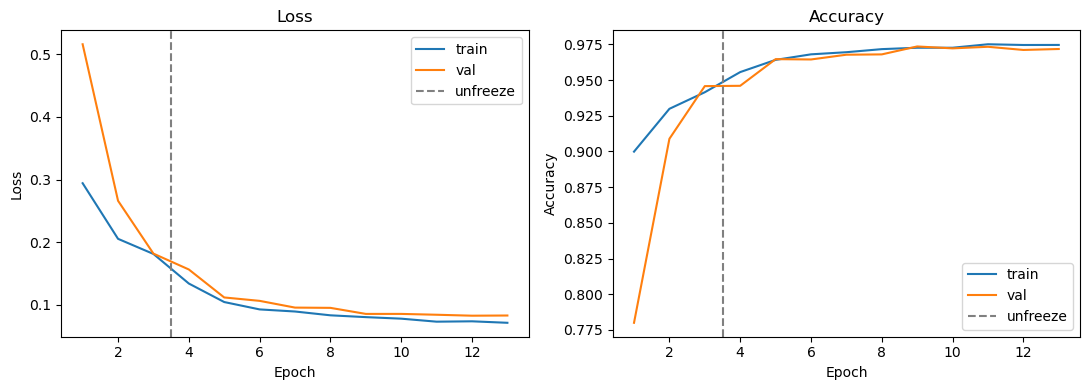

In [7]:
import matplotlib.pyplot as plt

total_epochs = EPOCHS_HEAD + EPOCHS_FULL
epochs = range(1, total_epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(epochs, history['train_loss'], label='train')
ax1.plot(epochs, history['val_loss'],   label='val')
ax1.axvline(EPOCHS_HEAD + 0.5, color='gray', linestyle='--', label='unfreeze')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Loss'); ax1.legend()

ax2.plot(epochs, history['train_acc'], label='train')
ax2.plot(epochs, history['val_acc'],   label='val')
ax2.axvline(EPOCHS_HEAD + 0.5, color='gray', linestyle='--', label='unfreeze')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.set_title('Accuracy'); ax2.legend()

plt.tight_layout()
plt.show()

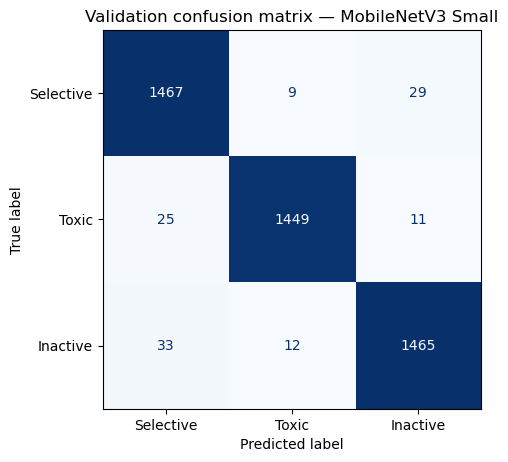

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.load_state_dict(torch.load(CKPT_DIR / 'best_model_v3.pt', map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        preds = model(imgs.to(device)).argmax(dim=1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Selective', 'Toxic', 'Inactive'])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Validation confusion matrix — MobileNetV3 Small')
plt.tight_layout()
plt.show()